# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [117]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
from sklearn.metrics import accuracy_score


### Step 1. Load the data

In [118]:
df= pd.read_csv('https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv')
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [119]:
X = df[['Experience Years']]

y = df['Salary']    

### Step 2.b print the type of each

In [120]:
print("Type of X:", type (X))
print("Type of y:", type (y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [121]:
if is_numeric_dtype (y):
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"  

print (f"Target type : {target_type}")
print (f"Machine Learning Task: {ml_task}")

Target type : Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [122]:
x_samples , x_columns = X.shape

y_samples = y.shape[0]

# In case y is a Series, it doesn't have a second index for columns, 
# but for clarity in this task, we can say it has 1 target column.
y_columns = 1 if len(y.shape) == 1 else y.shape[1]

# Print the results for X
print(f"Data Matrix (X): {x_samples} samples, {x_columns} column(s)")

# Print the results for y
print(f"Target Vector (y): {y_samples} samples, {y_columns} column(s)")

Data Matrix (X): 40 samples, 1 column(s)
Target Vector (y): 40 samples, 1 column(s)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [123]:
summary = df.describe()
summary.loc['median'] = df.median()   
print(summary)  

        Experience Years         Salary
count          40.000000      40.000000
mean            5.152500   74743.625000
std             2.663715   25947.122885
min             1.100000   37731.000000
25%             3.200000   56878.250000
50%             4.600000   64472.500000
75%             6.875000   95023.250000
max            10.500000  122391.000000
median          4.600000   64472.500000


### Step 5. Plot the feature vs the target

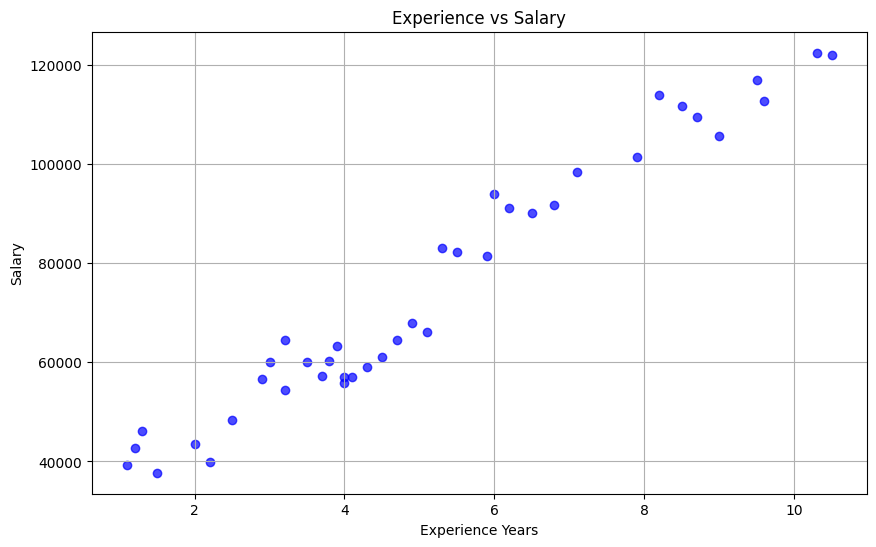

In [124]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Points', alpha=0.7)

plt.title('Experience vs Salary')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [125]:
correlation_value = df['Experience Years'].corr(df['Salary'])

if correlation_value > 0:
    Relationship = "Increasing (Positive Correlation)"
elif correlation_value < 0:
    Relationship = "Decreasing (Negative Correlation)"
else:
    Relationship = "No Correlation"

print(f"Correlation Value: {correlation_value:.2f}")
print(f"Relationship between Experience and Salary: {Relationship}")

Correlation Value: 0.98
Relationship between Experience and Salary: Increasing (Positive Correlation)


### Step 7. Initialize a regression model

In [126]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 32 samples
Testing set size: 8 samples


### Step 9.a Train the model on the training set

In [128]:
model.fit(X_train, y_train)
#print("Model training completed.")

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [129]:
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope (m / b1): {slope:.4f}")
print(f"Y-Intercept (c / b0): {intercept:.4f}")

Slope (m / b1): 9408.0313
Y-Intercept (c / b0): 26716.2502


### Step 9.c how much salary does a person get with 2 years of experience?

In [130]:
Sal_after_2_years = model.coef_[0] * 2 + model.intercept_
print(f"Predicted Salary after 2 years of experience: {Sal_after_2_years:.2f}")

Predicted Salary after 2 years of experience: 45532.31


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [131]:
sal_increase_for_6_months = model.coef_[0] * 0.5
print(f"Predicted Salary increase for 6 months of experience: {sal_increase_for_6_months:.2f}")

Predicted Salary increase for 6 months of experience: 4704.02


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [132]:
Start_Salary = model.intercept_
print(f"Predicted Starting Salary (0 years of experience): {Start_Salary:.2f}")

Predicted Starting Salary (0 years of experience): 26716.25


### Step 10. Evaluate the model on the test set

In [133]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 48077731.17
RMSE: 6933.81
R-squared: 0.91


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [134]:
X_samples = X_test.head(3)
y_samples = y_test.head(3)

comparison = pd.DataFrame({
    'Actual Salary': y_samples.values,
    'Predicted Salary': model.predict(X_samples)
})
comparison['eroor'] = comparison['Actual Salary'] - comparison['Predicted Salary']

print(comparison)

   Actual Salary  Predicted Salary        eroor
0          61111      69052.390902 -7941.390902
1          56957      64348.375266 -7391.375266
2          55794      64348.375266 -8554.375266


### Step 12. Plot the data and the regression line

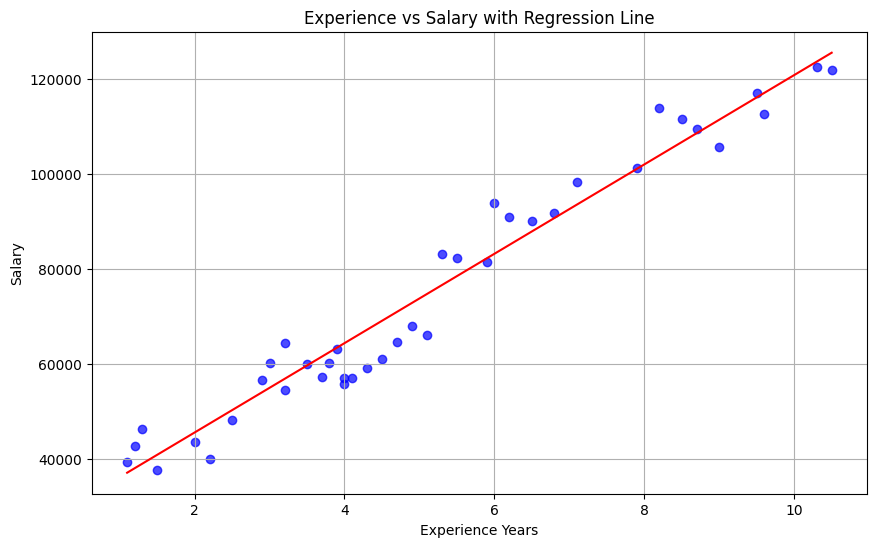

In [135]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Points', alpha=0.7)
plt.plot(X, model.predict(X), color='red', label='Regression Line')

plt.title('Experience vs Salary with Regression Line')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.grid(True)
plt.show()